In [1]:
# === Notebook common preamble (load the llm_math package) ===
import sys
from pathlib import Path

# Candidate paths for the llm_math package
_candidates = [
    '.', 'src', '..', '../src',
    '/content/llm-math-book/src',
    '/content/llm-math-book',
    '/workspace/src',
    '/workspace',
]
# Add parent directories as candidates (when running from the notebooks folder)
for p in Path.cwd().parents:
    _candidates.append(str(p / 'src'))
    _candidates.append(str(p))

for p in _candidates:
    if p and p not in sys.path and Path(p).exists():
        sys.path.insert(0, p)

# Try importing llm_math
try:
    from llm_math import viz, bench, data
    _LLM_MATH_OK = True
except ImportError as e:
    _LLM_MATH_OK = False
    print(f"[Warning] load the llm_math package text: {e}")
    print("  Clone the GitHub repository and run colab_setup.sh.")
# === end preamble ===


# Ch 05. Information Theory — text KL text

> **Learning Goals**
> - text $H(X)$text "text text"text text
> - text text text LLM Trainingtext text text text
> - KL text text Distributiontext text text text text

## 5.1 text text

**text(information)**: text text text "text"

$$I(x) = -\log P(x)$$

- text text text ($P$ text): text text
- text text ($P$ text): text text
- text: log text 2text bit, etext nat

**text(entropy)**: text textValue = Distributiontext text

$$H(X) = -\sum_x P(x) \log P(x) = \mathbb{E}[I(X)]$$


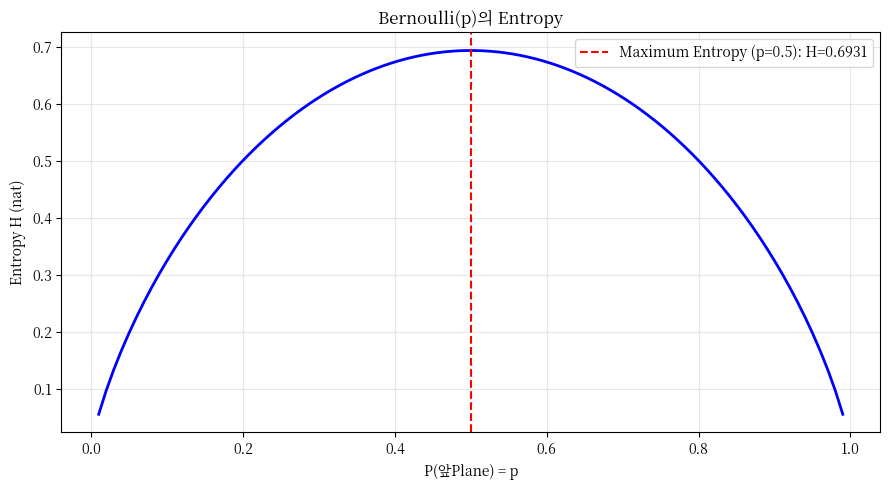

p=0.5 (text text)text text text text. p=0 text 1 (text)text text 0.


In [2]:
import numpy as np
import matplotlib.pyplot as plt

def entropy(p):
    """text Distributiontext Entropy (text e)."""
    p = np.asarray(p, dtype=float)
    p = p[p > 0]  # 0text text text (0*log0 = 0)
    return -np.sum(p * np.log(p))

# text text Entropy: ptext 0.5text text Maximum
ps = np.linspace(0.01, 0.99, 100)
entropies = [entropy([p, 1-p]) for p in ps]

plt.figure(figsize=(9, 5))
plt.plot(ps, entropies, 'b-', linewidth=2)
plt.axvline(0.5, color='r', linestyle='--', label=f'Maximum Entropy (p=0.5): H={entropy([0.5, 0.5]):.4f}')
plt.xlabel('P(textPlane) = p')
plt.ylabel('Entropy H (nat)')
plt.title('Bernoulli(p)text Entropy')
plt.legend(); plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('../figures/ch05_entropy_coin.png', dpi=100, bbox_inches='tight')
plt.show()
print("p=0.5 (text text)text text text text. p=0 text 1 (text)text text 0.")


## 5.2 text text (Cross-Entropy)

text Distribution $P$ (Answer)text $Q$ (text)text text:

$$H(P, Q) = -\sum_x P(x) \log Q(x)$$

text: $P$text $Q$text Encodingtext text text text text text.

**text**:
$$H(P, Q) = H(P) + D_{\mathrm{KL}}(P \| Q)$$

- $H(P)$: Answer Distributiontext text (text)
- $D_{\mathrm{KL}}$: $P$text $Q$text text

text **text text text = KL text text = $Q$text $P$text text**.

LLM Trainingtext Answer text $y$text text $P$text text $Q = \mathrm{softmax}(\mathbf{z})$text text:
$$\mathcal{L} = H(P, Q) = -\log Q(y) = -\log \mathrm{softmax}(\mathbf{z})_y$$

text **text text textdegrees(NLL)**text **text text text**.


In [3]:
# text text text text
def cross_entropy_loss(logits, target_idx):
    """text text text text Entropy Loss."""
    # softmax
    z = logits - logits.max()
    exp_z = np.exp(z)
    probs = exp_z / exp_z.sum()
    # -log p(target)
    return -np.log(probs[target_idx] + 1e-12), probs

# text
logits = np.array([2.0, 1.0, 0.5, -0.5])
target = 0  # Labeltext text text text
loss, probs = cross_entropy_loss(logits, target)
print(f"text: {logits}")
print(f"text Probability: {probs.round(4)}")
print(f"Label text text: {target}")
print(f"text Entropy Loss: {loss:.4f}")
print(f"Label Probability: {probs[target]:.4f} -> -log = {-np.log(probs[target]):.4f}")

# text Answer text text text text
print("\nLabel text text Losstext text:")
for correct_logit in [0.0, 1.0, 2.0, 5.0, 10.0]:
    logits_test = np.array([correct_logit, 0.0, 0.0, 0.0])
    loss, _ = cross_entropy_loss(logits_test, 0)
    print(f"  Label text={correct_logit:>5.1f} -> Loss={loss:.4f}")


text: [ 2.   1.   0.5 -0.5]
text Probability: [0.5977 0.2199 0.1334 0.0491]
Label text text: 0
text Entropy Loss: 0.5147
Label Probability: 0.5977 -> -log = 0.5147

Label text text Losstext text:
  Label text=  0.0 -> Loss=1.3863
  Label text=  1.0 -> Loss=0.7437
  Label text=  2.0 -> Loss=0.3408
  Label text=  5.0 -> Loss=0.0200
  Label text= 10.0 -> Loss=0.0001


## 5.3 KL text (Kullback-Leibler Divergence)

text Distribution $P, Q$text text text textdegrees:

$$D_{\mathrm{KL}}(P \| Q) = \sum_x P(x) \log \frac{P(x)}{Q(x)}$$

text:
1. $D_{\mathrm{KL}}(P \| Q) \geq 0$ (text)
2. $D_{\mathrm{KL}}(P \| Q) = 0 \iff P = Q$
3. **text**: $D_{\mathrm{KL}}(P \| Q) \neq D_{\mathrm{KL}}(Q \| P)$ (text text!)

LLMtext KL text:
- **RLHF**: text Modeltext text Modeltext text text (KL text)
- **text(Distillation)**: text Modeltext Output Distributiontext text Modeltext text
- **DPO**: text text Calculation


In [4]:
# KL text Calculation
def kl_divergence(p, q):
    """D_KL(P || Q)."""
    p = np.asarray(p, dtype=float)
    q = np.asarray(q, dtype=float)
    # 0text text text: P(x)=0textPlane text text 0
    mask = p > 0
    return np.sum(p[mask] * np.log(p[mask] / (q[mask] + 1e-12)))

# text Distributiontext
P = np.array([0.5, 0.3, 0.2])
Q1 = np.array([0.5, 0.3, 0.2])  # Ptext text
Q2 = np.array([0.4, 0.4, 0.2])  # text text
Q3 = np.array([0.7, 0.2, 0.1])  # text text

print(f"P  = {P}")
print(f"Q1 = {Q1} (Ptext text)")
print(f"Q2 = {Q2} (text text)")
print(f"Q3 = {Q3} (text text)")
print()
print(f"D_KL(P || Q1) = {kl_divergence(P, Q1):.6f} (0text text)")
print(f"D_KL(P || Q2) = {kl_divergence(P, Q2):.6f}")
print(f"D_KL(P || Q3) = {kl_divergence(P, Q3):.6f}")
print()
print("textSymmetrictext text:")
print(f"D_KL(P || Q3) = {kl_divergence(P, Q3):.6f}")
print(f"D_KL(Q3 || P) = {kl_divergence(Q3, P):.6f}")
print("=> text Valuetext text. KL Divergencetext Distancetext text.")


P  = [0.5 0.3 0.2]
Q1 = [0.5 0.3 0.2] (Ptext text)
Q2 = [0.4 0.4 0.2] (text text)
Q3 = [0.7 0.2 0.1] (text text)

D_KL(P || Q1) = -0.000000 (0text text)
D_KL(P || Q2) = 0.025267
D_KL(P || Q3) = 0.092033

textSymmetrictext text:
D_KL(P || Q3) = 0.092033
D_KL(Q3 || P) = 0.085123
=> text Valuetext text. KL Divergencetext Distancetext text.


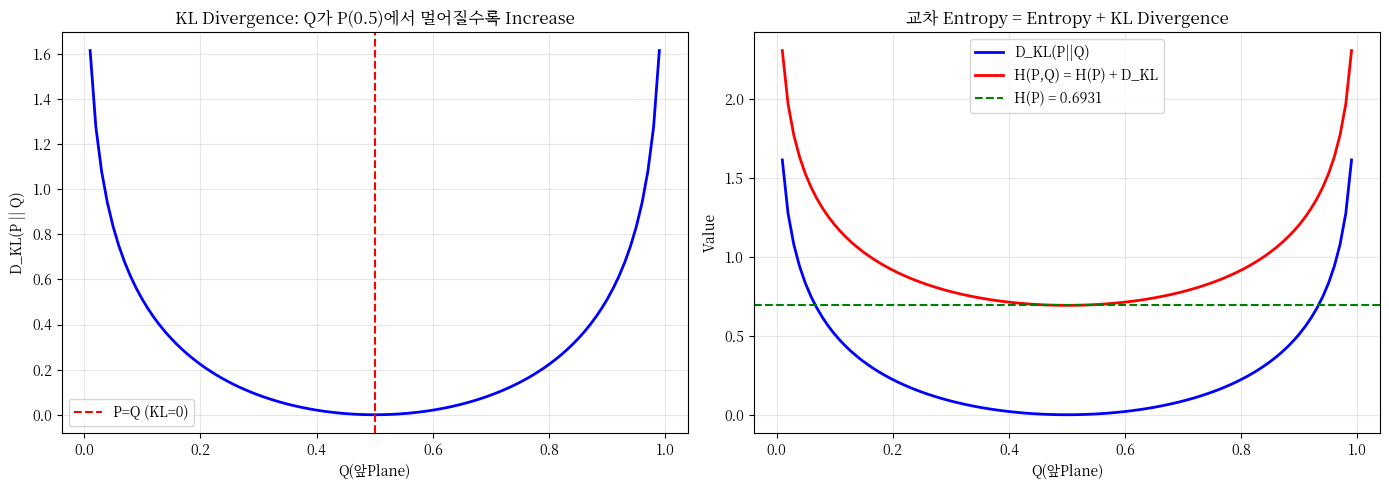

In [5]:
# KL text Visualization: Distributiontext text KL text
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# text: text Qtext text KL
ax = axes[0]
P = np.array([0.5, 0.5])
qs = np.linspace(0.01, 0.99, 100)
kls = [kl_divergence(P, [q, 1-q]) for q in qs]
ax.plot(qs, kls, 'b-', linewidth=2)
ax.axvline(0.5, color='r', linestyle='--', label='P=Q (KL=0)')
ax.set_xlabel('Q(textPlane)')
ax.set_ylabel('D_KL(P || Q)')
ax.set_title('KL Divergence: Qtext P(0.5)text text Increase')
ax.legend(); ax.grid(True, alpha=0.3)

# text: text text = H(P) + D_KL(P||Q)
ax = axes[1]
H_P = entropy(P)
ces = [H_P + kl for kl in kls]
ax.plot(qs, kls, 'b-', linewidth=2, label='D_KL(P||Q)')
ax.plot(qs, ces, 'r-', linewidth=2, label='H(P,Q) = H(P) + D_KL')
ax.axhline(H_P, color='g', linestyle='--', label=f'H(P) = {H_P:.4f}')
ax.set_xlabel('Q(textPlane)')
ax.set_ylabel('Value')
ax.set_title('text Entropy = Entropy + KL Divergence')
ax.legend(); ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('../figures/ch05_kl_divergence.png', dpi=100, bbox_inches='tight')
plt.show()


## 5.4 Perplexity (PPL)

LLM text text. Distributiontext "textdegrees"text text, text text:

$$\mathrm{PPL} = \exp(H) = \exp\left(-\frac{1}{T}\sum_{t=1}^{T} \log P(w_t | w_{<t})\right)$$

text: Modeltext text text text text "text text text text text".
- PPL = 1: text text
- PPL = |V|: text text (text text text)
- text text


text text:
  text Loss: ['7.12', '8.15', '7.34', '7.89', '9.52']
  Mean Loss: 8.0053
  PPL: 2996.72
  (Vocabulary Size 1000text text text)

text Prediction:
  text Loss: ['1.98', '2.09', '2.10', '1.96', '2.10']
  Mean Loss: 2.0469
  PPL: 7.74


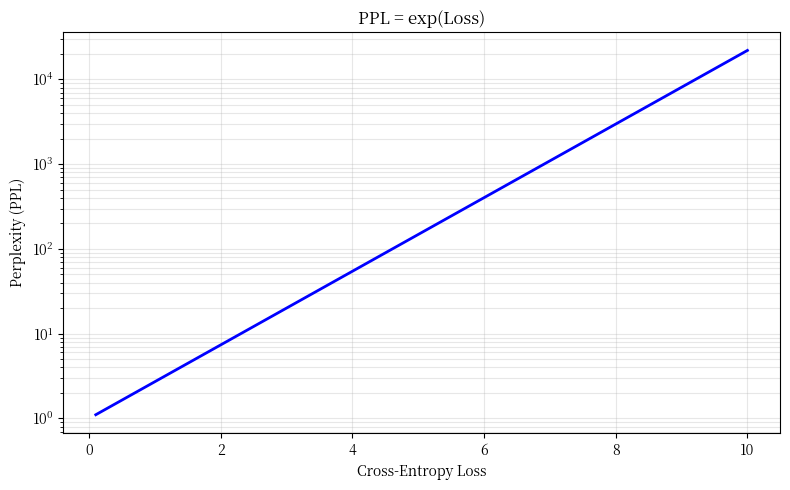

In [6]:
# Perplexity Calculation text
def perplexity(loss):
    """Mean text Entropy Losstext PPL Computation."""
    return np.exp(loss)

# text: 5text text text Prediction
np.random.seed(0)
seq_len = 5
vocab_size = 1000

# Modeltext Prediction text (text vs PointPoint text)
random_losses = []
good_losses = []

for t in range(seq_len):
    # text Prediction
    logits = np.random.randn(vocab_size)
    target = np.random.randint(vocab_size)
    loss, _ = cross_entropy_loss(logits, target)
    random_losses.append(loss)

    # text Prediction (Label text text)
    logits = np.random.randn(vocab_size) * 0.1
    target = np.random.randint(vocab_size)
    logits[target] += 5.0  # Label text text text
    loss, _ = cross_entropy_loss(logits, target)
    good_losses.append(loss)

print(f"text text:")
print(f"  text Loss: {[f'{l:.2f}' for l in random_losses]}")
print(f"  Mean Loss: {np.mean(random_losses):.4f}")
print(f"  PPL: {perplexity(np.mean(random_losses)):.2f}")
print(f"  (Vocabulary Size {vocab_size}text text text)")

print(f"\ntext Prediction:")
print(f"  text Loss: {[f'{l:.2f}' for l in good_losses]}")
print(f"  Mean Loss: {np.mean(good_losses):.4f}")
print(f"  PPL: {perplexity(np.mean(good_losses)):.2f}")

# PPL vs Loss text
losses = np.linspace(0.1, 10, 100)
ppls = np.exp(losses)
plt.figure(figsize=(8, 5))
plt.plot(losses, ppls, 'b-', linewidth=2)
plt.xlabel('Cross-Entropy Loss')
plt.ylabel('Perplexity (PPL)')
plt.title('PPL = exp(Loss)')
plt.yscale('log')
plt.grid(True, alpha=0.3, which='both')
plt.tight_layout()
plt.savefig('../figures/ch05_ppl.png', dpi=100, bbox_inches='tight')
plt.show()


## 5.5 text text (Mutual Information)

text text text $X, Y$text text text:

$$I(X; Y) = D_{\mathrm{KL}}(P_{X,Y} \| P_X \otimes P_Y) = H(X) - H(X | Y)$$

- $I(X; Y) = 0$: text
- $I(X; Y)$ text text text

LLMtext Attentiontext text "text text text" Trainingtext text text text.


In [7]:
# text text text: text text (text vs text)
def mutual_information(joint):
    """2x2 textSum Distributiontext text Information."""
    joint = np.asarray(joint, dtype=float)
    px = joint.sum(axis=1, keepdims=True)
    py = joint.sum(axis=0, keepdims=True)
    independent = px @ py
    mask = joint > 0
    return np.sum(joint[mask] * np.log(joint[mask] / independent[mask]))

# Independenttext text text
joint_indep = np.array([[0.25, 0.25],
                        [0.25, 0.25]])
# text Correlation (X=Y)
joint_corr = np.array([[0.5, 0.0],
                        [0.0, 0.5]])
# text Correlation
joint_weak = np.array([[0.4, 0.1],
                       [0.1, 0.4]])

print(f"text: MI = {mutual_information(joint_indep):.6f} (0text text)")
print(f"text Correlation: MI = {mutual_information(joint_weak):.6f}")
print(f"text Correlation: MI = {mutual_information(joint_corr):.6f}")


text: MI = 0.000000 (0text text)
text Correlation: MI = 0.192745
text Correlation: MI = 0.693147


## 5.6 Key Takeaways

| text | text | text |
|---|---|---|
| text | $I(x) = -\log P(x)$ | text text |
| text | $H(X) = -\sum P\log P$ | text text |
| text text | $H(P, Q) = -\sum P\log Q$ | LLM text Function |
| KL text | $D_{KL}(P\|Q) = \sum P\log\frac{P}{Q}$ | Distribution text (text) |
| text | $H(P,Q) = H(P) + D_{KL}(P\|Q)$ | CE text = KL text |
| PPL | $\exp(H)$ | Model textdegrees |

## Exercises

1. 4text text(text)text text Calculationtext. 6text text Comparisontext.
2. text Distribution $P=[0.7, 0.2, 0.1]$, $Q=[0.5, 0.3, 0.2]$text text $H(P)$, $H(P, Q)$, $D_{KL}(P\|Q)$text Calculationtext $H(P,Q) = H(P) + D_{KL}(P\|Q)$text Verificationtext.
3. text text 50000text LLMtext text text text PPLtext text?
4. KL text text text text. forward KL $D_{KL}(P\|Q)$text reverse KL $D_{KL}(Q\|P)$text text text.
5. text text text NLL(text text textdegrees)text text textdegreestext.

> Solutions: `solutions/ch05_solutions.ipynb`
